# Market Basket Analysis & Rekomendasi Produk

Nama  : Hadhist Rizqi Fauzhi

NIM   : 250401020093

Kelas : IF405

In [1]:
!pip install mlxtend

### Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
import warnings
warnings.simplefilter("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Generate & Eksplorasi Dataset

In [5]:
produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

transaksi = []

# Membuat 50 transaksi
for i in range(50):
    jumlah_item = np.random.randint(2, 6)
    item = list(np.random.choice(produk, jumlah_item, replace=False))
    transaksi.append(item)

# Menambahkan pola tersembunyi:
# Roti sering dibeli bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:", transaksi[:3])
print("Jumlah transaksi:", len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


,Produk,Frekuensi
4,Selai,26
5,Teh,23
2,Mentega,21
7,Telur,18
0,Keju,17
1,Roti,16
3,Kopi,16
6,Susu,16
8,Gula,16
9,Sereal,9


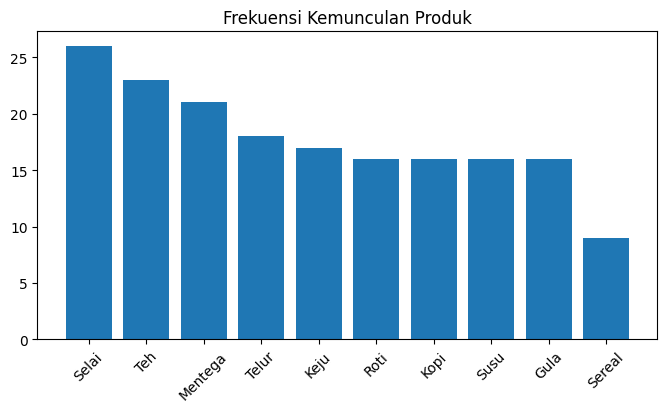

In [6]:
# Menghitung frekuensi kemunculan produk

frekuensi = {}

for trx in transaksi:
    for item in trx:
        frekuensi[item] = frekuensi.get(item, 0) + 1

freq_df = (
    pd.DataFrame(frekuensi.items(), columns=["Produk", "Frekuensi"])
      .sort_values("Frekuensi", ascending=False)
)

display(freq_df)

plt.figure(figsize=(8,4))
plt.bar(freq_df["Produk"], freq_df["Frekuensi"])
plt.xticks(rotation=45)
plt.title("Frekuensi Kemunculan Produk")
plt.show()

Dataset sintetis berhasil dibuat sebanyak 50 transaksi. Visualisasi frekuensi menunjukkan bahwa beberapa produk muncul lebih sering dibanding produk lainnya. Pola pembelian Roti bersama Selai juga mulai terlihat karena memang telah disisipkan pada proses pembuatan data.

### One Hot Encoding

In [15]:
te = TransactionEncoder()

te_array = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

display(df.head())

,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


Data transaksi berhasil diubah menjadi bentuk One-Hot Encoding, sehingga setiap produk direpresentasikan sebagai nilai True atau False. Format ini diperlukan sebagai input algoritma Apriori.

Frequent Itemset

In [8]:
for ms in [0.05, 0.1, 0.2]:

    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


In [16]:
freq_items = apriori(
    df,
    min_support=0.10,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    by="support",
    ascending=False
)

display(freq_items.head(10))

,support,itemsets
5,0.52,(Selai)
8,0.46,(Teh)
3,0.42,(Mentega)
9,0.36,(Telur)
1,0.34,(Keju)
0,0.32,(Gula)
2,0.32,(Kopi)
4,0.32,(Roti)
7,0.32,(Susu)
36,0.24,"(Teh, Selai)"


Nilai min_support mempengaruhi jumlah itemset yang ditemukan. Semakin kecil nilai support maka semakin banyak kombinasi produk yang muncul. Pada praktikum ini digunakan min_support = 0.10 karena menghasilkan jumlah itemset yang masih mudah dianalisis.

### Association Rules

In [10]:
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[
    rules["lift"] > 1
].sort_values(
    by="lift",
    ascending=False
)

print(
rules[
[
'antecedents',
'consequents',
'support',
'confidence',
'lift'
]
].head(10)
)

         antecedents consequents  support  confidence      lift
9        (Teh, Keju)     (Telur)     0.12    0.857143  2.380952
14  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
11      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
8       (Teh, Telur)      (Keju)     0.12    0.600000  1.764706
15     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
10     (Telur, Keju)       (Teh)     0.12    0.750000  1.630435
12     (Selai, Gula)      (Roti)     0.10    0.500000  1.562500
13   (Mentega, Kopi)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115




* Aturan dengan nilai Lift tertinggi merupakan hubungan yang paling kuat.
* Jika muncul aturan Roti → Selai, maka aturan tersebut sesuai dengan pola yang memang disisipkan ketika membuat dataset.
* Nilai Lift > 1 menunjukkan bahwa kedua produk memiliki hubungan pembelian yang lebih kuat dibandingkan kejadian secara acak.






Association Rules berhasil menemukan hubungan antar produk berdasarkan riwayat transaksi. Aturan dengan nilai Lift tinggi dapat dimanfaatkan sebagai rekomendasi produk ketika pelanggan melakukan pembelian.

### Content-Based Filtering

In [11]:
katalog = pd.DataFrame({
    "produk": produk,
    "kategori": [
        "Bakery",
        "Bakery",
        "Dairy",
        "Bakery",
        "Dairy",
        "Dairy",
        "Minuman",
        "Bumbu",
        "Minuman",
        "Dairy"
    ]
})

display(katalog)

,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Bakery
4,Telur,Dairy
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy


In [17]:
fitur = pd.get_dummies(katalog["kategori"])

sim_matrix = cosine_similarity(fitur)

similarity = pd.DataFrame(
    sim_matrix,
    index=katalog["produk"],
    columns=katalog["produk"]
)

display(similarity.round(2))

produk,Roti,Selai,Susu,Sereal,Telur,Keju,Kopi,Gula,Teh,Mentega
produk,,,,,,,,,,
Roti,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Selai,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Susu,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Sereal,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Telur,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Keju,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Kopi,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
Gula,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Teh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [13]:
def rekomendasi_serupa(nama_produk, top_n=3):

    idx = katalog.index[
        katalog["produk"] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    hasil = katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()

    return hasil

print("Rekomendasi produk mirip dengan Roti:")
print(rekomendasi_serupa("Roti"))

Rekomendasi produk mirip dengan Roti:
['Selai', 'Sereal', 'Susu']


Metode Content-Based Filtering memberikan rekomendasi berdasarkan kesamaan kategori produk. Produk yang berada pada kategori yang sama memiliki nilai cosine similarity yang tinggi sehingga direkomendasikan sebagai alternatif.

### Perbandingan Kedua Pendekatan

In [14]:
produk_target = "Roti"

rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
]

print("Rekomendasi dari Association Rules:")

print(
rules_terkait[
[
'consequents',
'lift'
]
].head()
)

print()

print(
"Rekomendasi dari Content-Based:",
rekomendasi_serupa(produk_target)
)

Rekomendasi dari Association Rules:
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


Association Rules

* Menghasilkan rekomendasi berdasarkan pola pembelian pelanggan.
* Contohnya apabila pelanggan membeli Roti, sistem merekomendasikan Selai karena sering dibeli bersamaan.

Content-Based Filtering

* Menghasilkan rekomendasi berdasarkan karakteristik produk.
* Untuk produk Roti, sistem lebih banyak merekomendasikan produk lain dalam kategori Bakery, seperti Selai atau Sereal, tanpa melihat riwayat transaksi.

Kedua pendekatan dapat menghasilkan rekomendasi yang sama maupun berbeda. Association Rules lebih efektif ketika tersedia banyak data transaksi, sedangkan Content-Based Filtering tetap dapat digunakan meskipun data transaksi masih sedikit. Dalam implementasi nyata, kedua metode sering digabungkan menjadi Hybrid Recommendation System agar hasil rekomendasi menjadi lebih relevan.

### Kesimpulan

Pada praktikum ini telah diterapkan dua metode rekomendasi, yaitu Association Rules menggunakan algoritma Apriori dan Content-Based Filtering menggunakan cosine similarity. Apriori berhasil menemukan hubungan antar produk berdasarkan pola transaksi pelanggan, sedangkan Content-Based Filtering memberikan rekomendasi berdasarkan kesamaan kategori produk.

Hasil perbandingan menunjukkan bahwa Association Rules lebih tepat digunakan untuk menemukan produk yang sering dibeli secara bersamaan, sementara Content-Based Filtering lebih sesuai untuk merekomendasikan produk dengan karakteristik yang mirip. Penggabungan kedua metode dapat menghasilkan sistem rekomendasi yang lebih akurat dan bermanfaat dalam meningkatkan pengalaman pelanggan maupun penjualan.